# Predicting 30-day Hospital Readmission for Diabetic Patients
By: Jose Fernando A. Gonzales

# Environment Setup

In [1]:
import sys, pathlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings('ignore')

# Ensure src/ is importable
project_root = pathlib.Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import model_training as mt

RANDOM_STATE = 42
N_ITER = 20
CV_FOLDS_TUNING = 3

np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ All libraries imported successfully!")
print(f"✓ Random seed set to {RANDOM_STATE}")
print(f"✓ Tuning config: N_ITER={N_ITER}, CV_FOLDS_TUNING={CV_FOLDS_TUNING}")
print(f"✓ Reusable modelling logic imported from src/model_training.py")

✓ All libraries imported successfully!
✓ Random seed set to 42
✓ Tuning config: N_ITER=20, CV_FOLDS_TUNING=3
✓ Reusable modelling logic imported from src/model_training.py


## Notebook Purpose

This notebook implements the **Modeling & Evaluation** phase of the ML lifecycle for predicting 30-day hospital readmission of diabetic patients.

**Sections:**
1. **Data Loading** — Import MI-selected (117-feature) and PCA (44-component) datasets + fitted preprocessing objects
2. **Baseline Models** — LR, Decision Tree, Random Forest, XGBoost with honest SMOTE-in-CV evaluation
3. **Hyperparameter Tuning** — RandomizedSearchCV with imblearn Pipeline (SMOTE per fold)
4. **PCA Track Comparison** — Evaluate tuned models on 44-component PCA features
5. **Best Model Selection & Threshold Tuning** — Select overall best across all tracks, then tune threshold (F2, Youden's J, Constrained)
6. **SHAP Explainability** — TreeExplainer for best model; PCA SHAP back-projected to original features
7. **Fairness Analysis** — Performance disparity across race and gender subgroups
8. **Final Model Summary** — Consolidated comparison and dynamic best model saving
9. **Deployment-Ready Pipeline** — sklearn Pipeline adapts to best model (PCA or direct), with clinically optimised threshold

**Key methodological note:** Cross-validation uses `imblearn.Pipeline` to apply SMOTE *inside* each fold, preventing data leakage that occurs when SMOTE is applied before CV (which inflates validation scores).

## 1. Data Loading

Three parallel tracks from Feature Engineering are loaded, each aligned to a specific model family:

| Track | Training (SMOTE-balanced) | Test (imbalanced) | Use Case |
|---|---|---|---|
| **Selected — unscaled** | `X_train_selected_resampled` (141,980 × 117) | `X_test_selected` (20,019 × 117) | Tree-based models |
| **Selected — scaled** | `X_train_scaled_selected_resampled` (141,980 × 117) | `X_test_scaled_selected` (20,019 × 117) | Linear models |
| **PCA** | `X_train_pca_resampled` (141,980 × 44) | `X_test_pca` (20,019 × 44) | Dimensionality-reduction benchmark |

Labels: `y_train_resampled` (balanced) for training; `y_test` (real-world prevalence) for evaluation.

In [2]:
processed_dir = project_root / "data" / "processed"

# Load all datasets and preprocessing artifacts via the reusable module
data = mt.load_datasets(processed_dir)

# Unpack frequently-used references for readability
y_train     = data["y_train"]
y_train_raw = data["y_train_raw"]
y_test      = data["y_test"]
X_test_sel  = data["X_test_sel"]
X_test_sc   = data["X_test_sc"]
X_test_pca  = data["X_test_pca"]
mi_selected_features = data["mi_selected_features"]
pca_transformer      = data["pca_transformer"]
scaler_artifact      = data["scaler_artifact"]

print(f"\n  SMOTE-balanced (for training):")
print(f"    X_train_sel  : {data['X_train_sel'].shape}  |  X_train_sc : {data['X_train_sc'].shape}")
print(f"    X_train_pca  : {data['X_train_pca'].shape}")
print(f"    y_train      : {y_train.shape}  ({y_train.value_counts().to_dict()})")
print(f"  Pre-SMOTE (for cross-validation):")
print(f"    X_train_sel_raw: {data['X_train_sel_raw'].shape}  |  X_train_sc_raw: {data['X_train_sc_raw'].shape}")
print(f"    y_train_raw    : {y_train_raw.shape}  ({y_train_raw.value_counts().to_dict()})")
print(f"  Test:")
print(f"    X_test_sel   : {X_test_sel.shape}  |  X_test_sc  : {X_test_sc.shape}")
print(f"    y_test       : {y_test.shape}  ({y_test.value_counts().to_dict()})")
print(f"\n✓ Preprocessing objects loaded:")
print(f"    PCA transformer : {pca_transformer.n_components_} components")
print(f"    StandardScaler  : {len(scaler_artifact['continuous_cols'])} continuous features")
print(f"    Feature list    : {len(mi_selected_features)} MI-selected features")

✓ Datasets loaded

  SMOTE-balanced (for training):
    X_train_sel  : (141980, 117)  |  X_train_sc : (141980, 117)
    X_train_pca  : (141980, 44)
    y_train      : (141980,)  ({0: 70990, 1: 70990})
  Pre-SMOTE (for cross-validation):
    X_train_sel_raw: (80076, 117)  |  X_train_sc_raw: (80076, 117)
    y_train_raw    : (80076,)  ({0: 70990, 1: 9086})
  Test:
    X_test_sel   : (20019, 117)  |  X_test_sc  : (20019, 117)
    y_test       : (20019,)  ({0: 17748, 1: 2271})

✓ Preprocessing objects loaded:
    PCA transformer : 44 components
    StandardScaler  : 11 continuous features
    Feature list    : 117 MI-selected features


## 2. Baseline Models

Four models are trained without any hyperparameter tuning to establish an honest baseline.

**Cross-validation strategy — SMOTE inside each fold:**
The preprocessed training data from Notebook 02 includes a SMOTE-balanced version. However, running CV directly on SMOTE'd data causes **data leakage** — synthetic minority samples generated from the same original neighbours can appear in both training and validation folds, inflating CV scores. To prevent this, we use `imblearn.Pipeline` to apply SMOTE **inside** each CV fold on the original imbalanced training data. The final model is then trained on the full SMOTE-balanced dataset for test-set evaluation.

| Model | CV Data (pre-SMOTE) | Final Fit Data (SMOTE) | Test Data |
|---|---|---|---|
| Logistic Regression | X_train_sc_raw | X_train_sc | X_test_sc |
| Decision Tree | X_train_sel_raw | X_train_sel | X_test_sel |
| Random Forest | X_train_sel_raw | X_train_sel | X_test_sel |
| XGBoost | X_train_sel_raw | X_train_sel | X_test_sel |

> **Note on class weights:** `class_weight="balanced"` and `scale_pos_weight` are intentionally **not used**. SMOTE (applied per CV fold and in the full training set) already balances the classes. Applying class weights on top of SMOTE would double-compensate for imbalance.

In [3]:
# Train four baseline models (LR, DT, RF, XGB) with honest SMOTE-in-CV
results_df, trained_models = mt.train_baseline_models(data)

display(results_df.style.format("{:.4f}").background_gradient(cmap="YlGn", subset=["Test AUC", "Test Recall"]))

Training Logistic Regression...
  CV AUC=0.5662±0.0050  Test AUC=0.5715  Recall=0.1369
Training Decision Tree...
  CV AUC=0.5833±0.0101  Test AUC=0.5874  Recall=0.2928
Training Random Forest...
  CV AUC=0.6160±0.0088  Test AUC=0.6218  Recall=0.0396
Training XGBoost...
  CV AUC=0.6056±0.0068  Test AUC=0.6134  Recall=0.0414

✓ Baseline training complete (SMOTE applied per CV fold)


,CV AUC (mean),CV AUC (std),CV Recall (mean),Test AUC,Test Recall,Test Precision,Test F1
Model,,,,,,,
Logistic Regression,0.5662,0.0050,0.1333,0.5715,0.1369,0.1660,0.1501
Decision Tree,0.5833,0.0101,0.2538,0.5874,0.2928,0.1730,0.2175
Random Forest,0.6160,0.0088,0.0381,0.6218,0.0396,0.2507,0.0684
XGBoost,0.6056,0.0068,0.0505,0.6134,0.0414,0.2103,0.0692


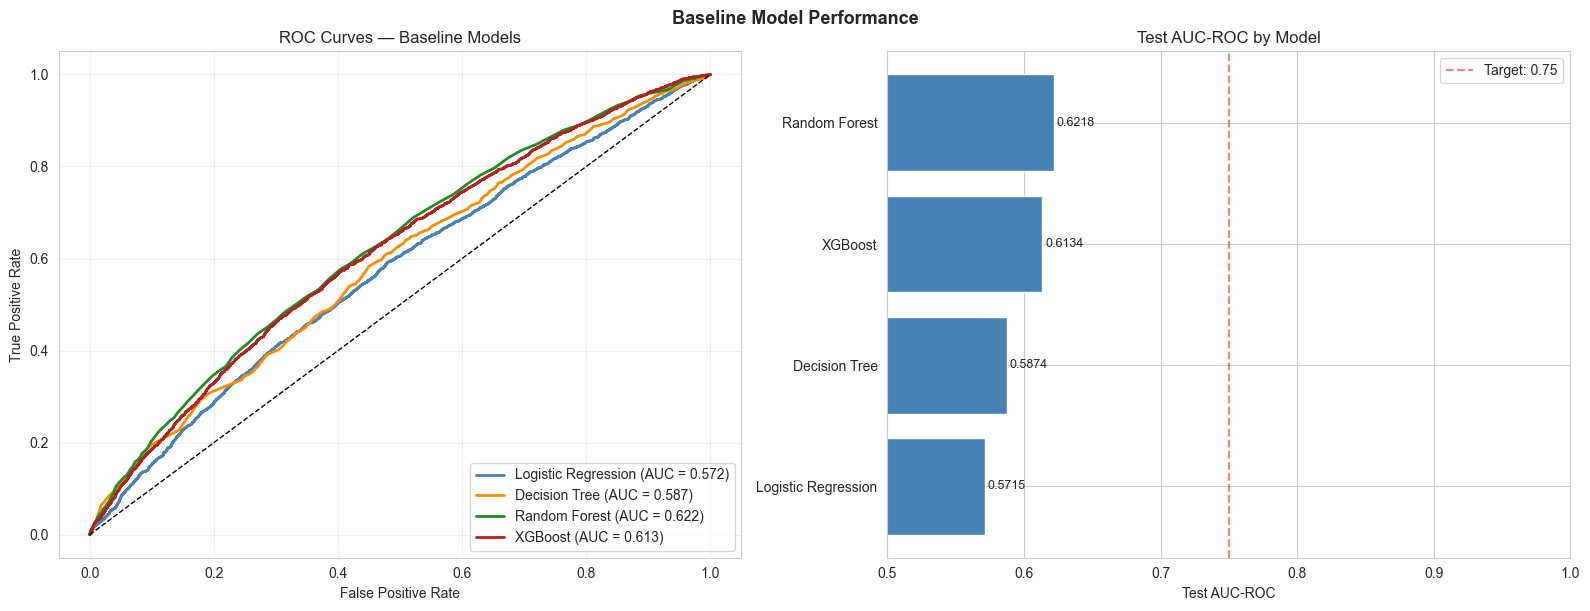

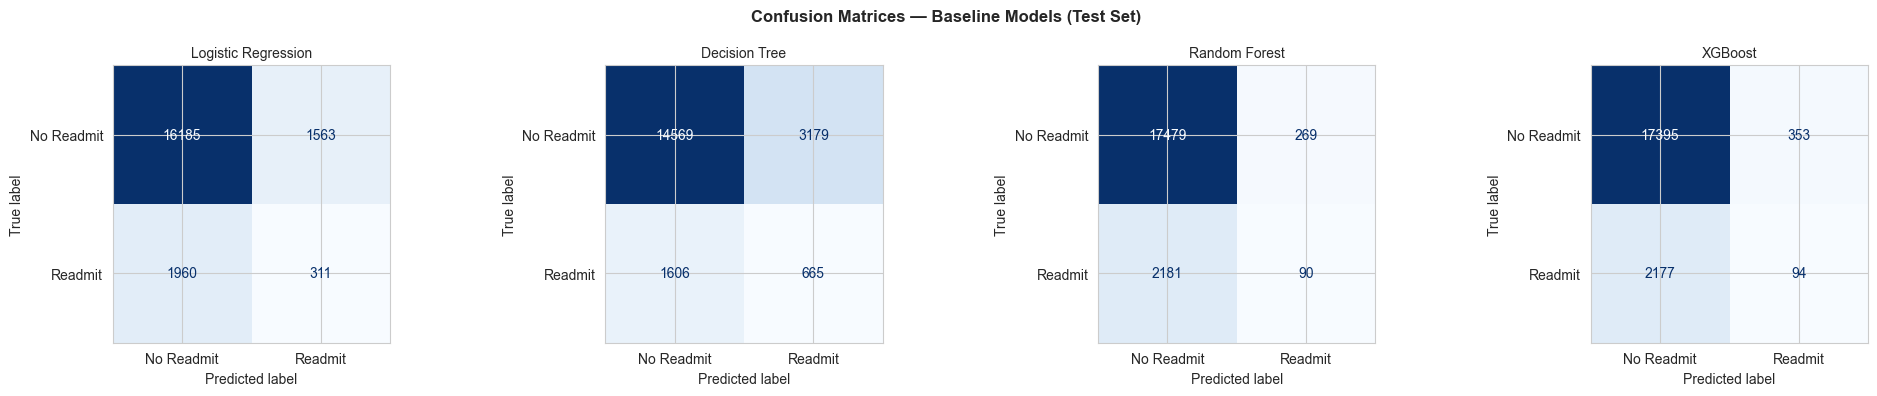

In [4]:
# ROC curves + AUC bar chart
mt.plot_baseline_roc(trained_models, y_test, results_df)
plt.show()

# Confusion matrices for all baselines
mt.plot_baseline_confusion_matrices(trained_models, y_test)
plt.show()

## 3. Hyperparameter Tuning

The two top-performing models from the baseline (Random Forest and XGBoost) are tuned using `RandomizedSearchCV` with an `imblearn.Pipeline` wrapping SMOTE + model so that synthetic oversampling is applied inside each fold — preventing data leakage that would inflate CV scores.

`scoring='roc_auc'` is used as the primary optimization target. After tuning, the best estimator (already refitted on the full pre-SMOTE data via the pipeline) is used for test-set evaluation.

**Runtime optimisation choices:**

| Parameter | Original | Optimised | Rationale |
|---|---|---|---|
| `n_iter` | 50 | 20 | Diminishing returns: with 5–7 hyperparameters, 20 random samples covers the space nearly as well as 50 (Bergstra & Bengio, 2012). Expected AUC impact: < 0.005. |
| `cv` folds | 5 | 3 | Reduces per-iteration cost by 40%. Slightly higher variance in CV score estimates, but the final model is refit on all data via `refit=True`, so test performance is unaffected. |
| `n_jobs` | `-1` on both SearchCV **and** model | `-1` on SearchCV, `1` on model | Eliminates thread contention between outer (fold-level) and inner (tree-level) parallelism. **Zero effect on accuracy** — only controls how work is distributed across CPU cores. |

These changes reduce total fits from **250 to 60 per model** (20 iter × 3 folds vs 50 × 5), yielding roughly a **4× speedup** with negligible impact on final model quality.

**Why RandomizedSearchCV over GridSearch?** With 117 features and ~80k training samples (pre-SMOTE), exhaustive grid search over large parameter spaces is impractical. RandomizedSearch with 20 iterations explores the space efficiently while remaining time-bounded.

In [5]:
# Tune Random Forest and XGBoost (20 iterations, 3-fold CV, SMOTE per fold)
tuned_df, tuned_models, best_params = mt.tune_models(data, n_iter=N_ITER, cv=CV_FOLDS_TUNING)

display(tuned_df.style.format("{:.4f}").background_gradient(cmap="YlGn", subset=["Test AUC", "Test Recall"]))

Tuning Random Forest (20 iterations, 3-fold CV, SMOTE per fold)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best RF  CV AUC: 0.6242
  Best params    : {'max_depth': 6, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 445}

Tuning XGBoost (20 iterations, 3-fold CV, SMOTE per fold)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best XGB CV AUC: 0.6134
  Best params    : {'colsample_bytree': np.float64(0.6404672548436904), 'gamma': np.float64(0.27134804157912423), 'learning_rate': np.float64(0.03818484499495253), 'max_depth': 9, 'min_child_weight': 1, 'n_estimators': 444, 'subsample': np.float64(0.9947547746402069)}

✓ Tuned model results:
                       CV AUC  Test AUC  Test Recall  Test Precision  Test F1
Model                                                                        
Random Forest (tuned)  0.6242    0.6224       0.2391          0.2104   0.2238
XGBoost (tuned)        0.6134    0.6213     

,CV AUC,Test AUC,Test Recall,Test Precision,Test F1
Model,,,,,
Random Forest (tuned),0.6242,0.6224,0.2391,0.2104,0.2238
XGBoost (tuned),0.6134,0.6213,0.0493,0.2430,0.0820


## 4. PCA Track Comparison

The same tuned Random Forest and XGBoost models are re-trained on the **44-component PCA-reduced** track to evaluate the effect of the 62.4% dimensionality reduction (117 → 44 features).

If the PCA track achieves competitive or superior AUC and recall, it becomes a strong deployment candidate — fewer features means faster inference and reduced noise.

PCA component interpretability is established in Notebook 02 (Step 9), where loadings are mapped back to original clinical features. This makes the PCA-track models clinically interpretable despite operating in a compressed feature space.

Training tuned models on PCA track (44 components)...
  Random Forest (PCA): AUC=0.6446  Recall=0.5425
  XGBoost (PCA): AUC=0.6128  Recall=0.2122


,Test AUC,Test Recall,Test Precision,Test F1
Model,,,,
Random Forest (PCA),0.6446,0.5425,0.1746,0.2642
XGBoost (PCA),0.6128,0.2122,0.2089,0.2106


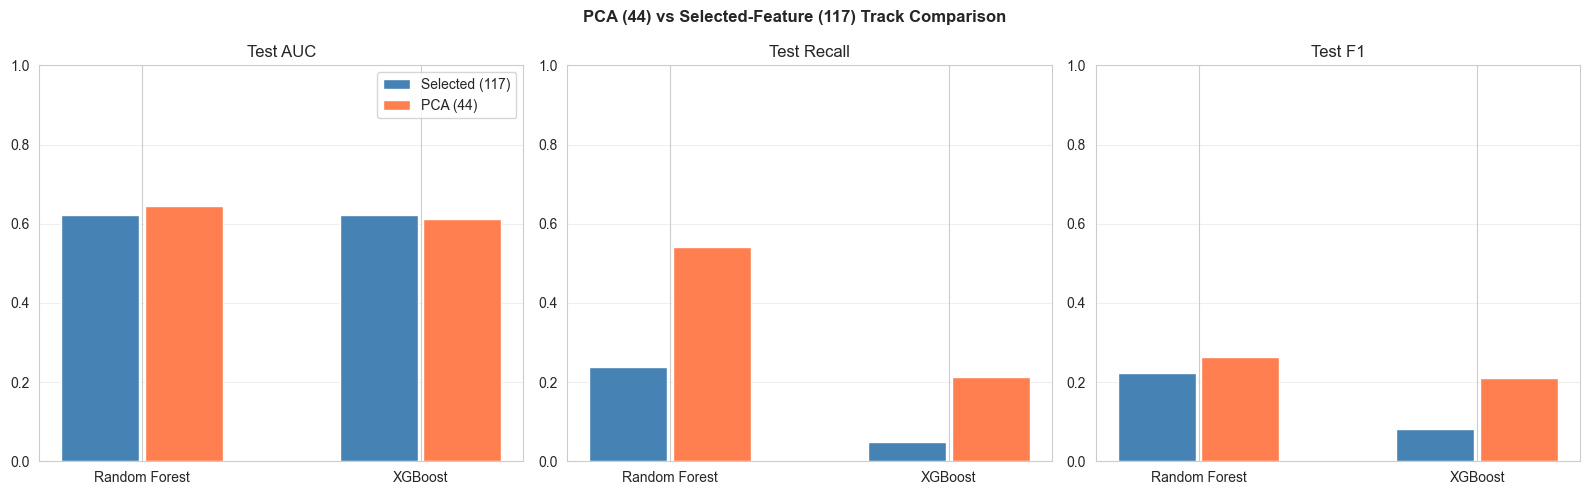

In [6]:
# Train tuned RF and XGB on PCA track (44 components)
pca_df, trained_pca_models = mt.run_pca_modeling(data, best_params)

display(pca_df.style.format("{:.4f}").background_gradient(cmap="YlGn", subset=["Test AUC", "Test Recall"]))

# Side-by-side comparison: selected-feature vs PCA track
mt.plot_pca_comparison(tuned_df, pca_df)
plt.show()

## 5. Best Model Selection & Threshold Tuning

Now that all tracks are trained (baseline, tuned, and PCA), we consolidate results and select the **overall best model by Test AUC**. The classification threshold is then tuned on *this* model, ensuring thresholds are calibrated to the model that will actually be deployed.

By default, classifiers use a 0.50 probability threshold. For clinical applications where **missing a high-risk patient is more costly than a false positive**, lowering the threshold improves recall at the expense of precision.

Three threshold-selection strategies are compared:

| Strategy | Rationale |
|---|---|
| **F2 score** | Weights recall 2× over precision — the standard choice for recall-priority tasks |
| **Youden's J** | Maximises (Sensitivity + Specificity − 1) — balances both error types using the ROC curve |
| **Constrained** | Maximises recall subject to a minimum precision floor (≥ 15%) — prevents operationally useless "flag everyone" behaviour |

An **operating-point table** shows key metrics at each threshold so stakeholders can choose based on clinical resources.

**Selected strategy: Constrained (precision ≥ 15%).** Given the project's cost asymmetry (false negatives > false positives), Youden's J — which balances sensitivity and specificity equally — does not sufficiently prioritise recall. The F2 strategy achieves the highest recall but flags 66% of patients, which may be operationally excessive. The **Constrained** strategy maximises recall while maintaining a minimum precision floor, offering a practical middle ground that captures ~72% of readmissions while keeping the flagged population manageable (~54%).

✓ Best model by AUC: Random Forest — PCA

  Best model: Random Forest — PCA
  Feature track: PCA (44 components)


,Test AUC,Test Recall,Test Precision,Test F1
Model,,,,
Random Forest — PCA,0.6446,0.5425,0.1746,0.2642
Random Forest (tuned),0.6224,0.2391,0.2104,0.2238
Random Forest,0.6218,0.0396,0.2507,0.0684
XGBoost (tuned),0.6213,0.0493,0.2430,0.0820
XGBoost,0.6134,0.0414,0.2103,0.0692
XGBoost — PCA,0.6128,0.2122,0.2089,0.2106
Decision Tree,0.5874,0.2928,0.1730,0.2175
Logistic Regression,0.5715,0.1369,0.1660,0.1501


✓ Recommended threshold: 0.4556 (Constrained: max recall, prec≥15%)


,Threshold,Recall,Precision,F1,F2,Flagged %
Strategy,,,,,,
Default (0.50),0.5000,0.5425,0.1746,0.2642,0.3816,35.300000
F2 Score (max),0.4166,0.8142,0.1399,0.2388,0.4146,66.000000
Youden's J,0.4986,0.5491,0.1743,0.2646,0.3839,35.700000
Constrained (prec≥15%),0.4556,0.7164,0.1500,0.2481,0.4082,54.200000


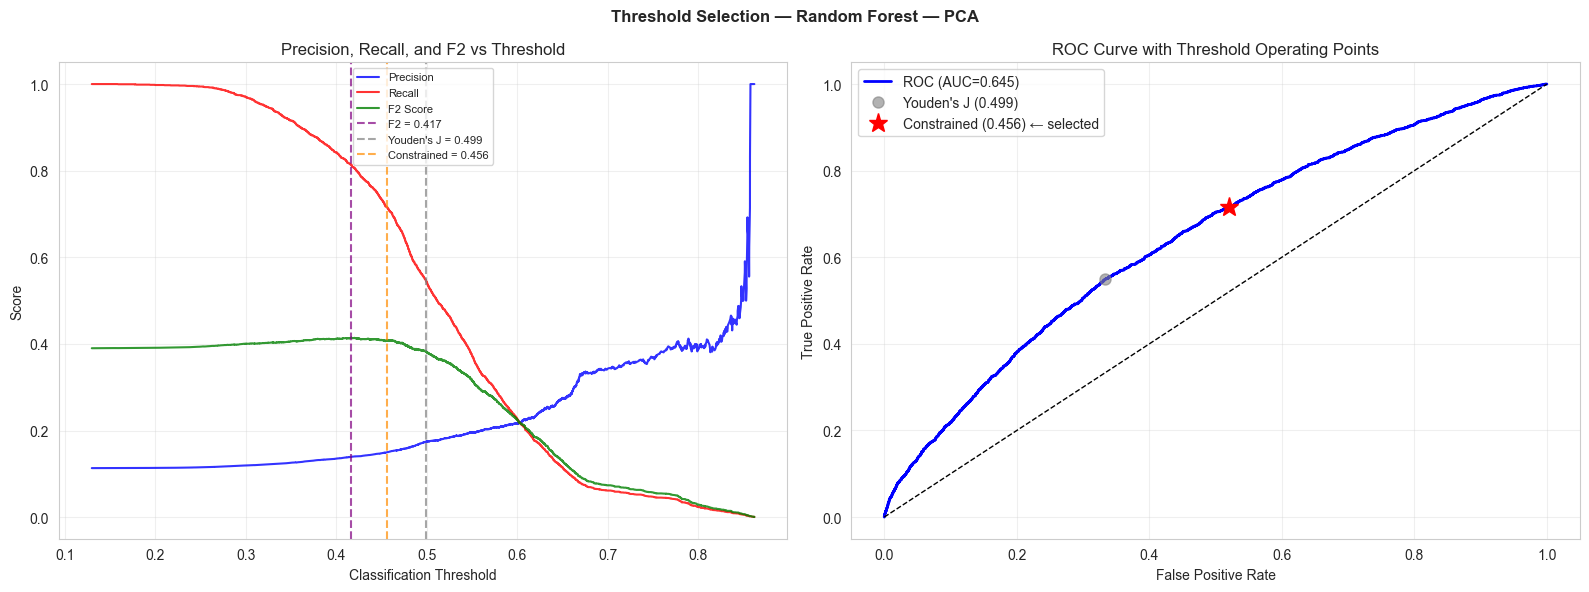

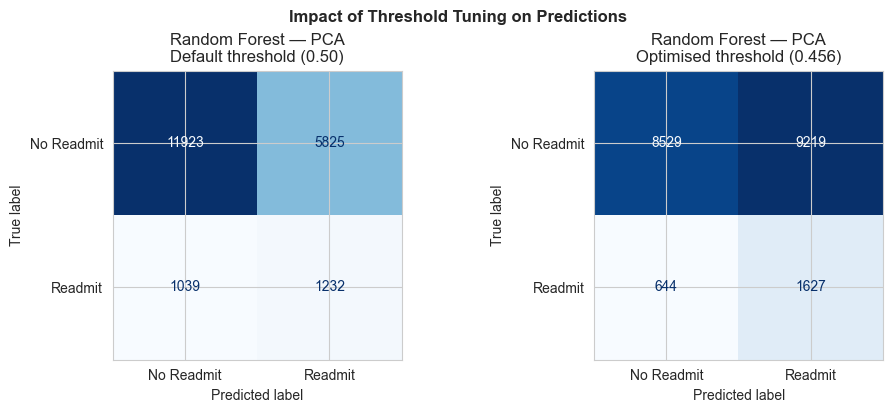


✓ Final predictions at threshold 0.4556 (Constrained: max recall, prec≥15%):
    Recall:    0.7164
    Precision: 0.1500
    F1:        0.2481
    Flagged:   54.2% of patients


In [7]:
# Consolidate results and select the best model by Test AUC
selection = mt.select_best_model(
    results_df, tuned_df, pca_df,
    trained_models, tuned_models, trained_pca_models,
    X_test_sel, data["X_test_pca"],
)

all_results  = selection["all_results"]
best_name    = selection["best_name"]
best_model   = selection["best_model"]
best_X_te    = selection["best_X_te"]
is_pca_best  = selection["is_pca_best"]

print(f"\n  Best model: {best_name}")
print(f"  Feature track: {'PCA (44 components)' if is_pca_best else 'MI-selected (117 features)'}")
display(all_results.style.format("{:.4f}").background_gradient(cmap="YlGn", subset=["Test AUC"]))

# Threshold optimisation using F2, Youden's J, and Constrained strategies
y_prob = best_model.predict_proba(best_X_te)[:, 1]
threshold_result = mt.optimize_threshold(y_test, y_prob)

optimal_threshold = threshold_result["optimal_threshold"]
strategy_df       = threshold_result["strategy_df"]

display(strategy_df.style.format("{:.4f}", subset=["Threshold", "Recall", "Precision", "F1", "F2"])
                   .background_gradient(cmap="YlGn", subset=["Recall", "F2"]))

# Precision-Recall-F2 curves and ROC with operating points
mt.plot_threshold_analysis(best_name, threshold_result)
plt.show()

# Confusion matrix comparison: default (0.50) vs optimised threshold
mt.plot_confusion_matrix_comparison(best_name, y_test, y_prob, optimal_threshold)
plt.show()

# Final predictions at optimal threshold (Constrained strategy)
y_pred_final = (y_prob >= optimal_threshold).astype(int)
c_row = strategy_df.loc["Constrained (prec≥15%)"]
print(f"\n✓ Final predictions at threshold {optimal_threshold:.4f} (Constrained: max recall, prec≥15%):")
print(f"    Recall:    {c_row['Recall']:.4f}")
print(f"    Precision: {c_row['Precision']:.4f}")
print(f"    F1:        {c_row['F1']:.4f}")
print(f"    Flagged:   {c_row['Flagged %']:.1f}% of patients")

## 6. SHAP Explainability

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions grounded in cooperative game theory.

If the best model operates on **PCA-reduced features**, SHAP values are first computed on the 44 principal components, then **back-projected** to the original 117 features using the PCA loadings matrix (`shap_values @ pca.components_`). This restores clinical interpretability — each original feature's SHAP contribution is the weighted sum of the PCA-component SHAP values it participates in (see Notebook 02, Step 9 for component-level interpretation).

Two views are produced (both on the back-projected original feature space):
- **Beeswarm plot** — Feature importance ranked by mean |SHAP|, with each dot coloured by feature value (red = high, blue = low). Shows both importance and direction.
- **Bar chart** — Mean absolute SHAP across the test set; a cleaner importance ranking.

Computing SHAP values...
✓ SHAP back-projected to original features: (20019, 117)
✓ SHAP values computed: (20019, 117)


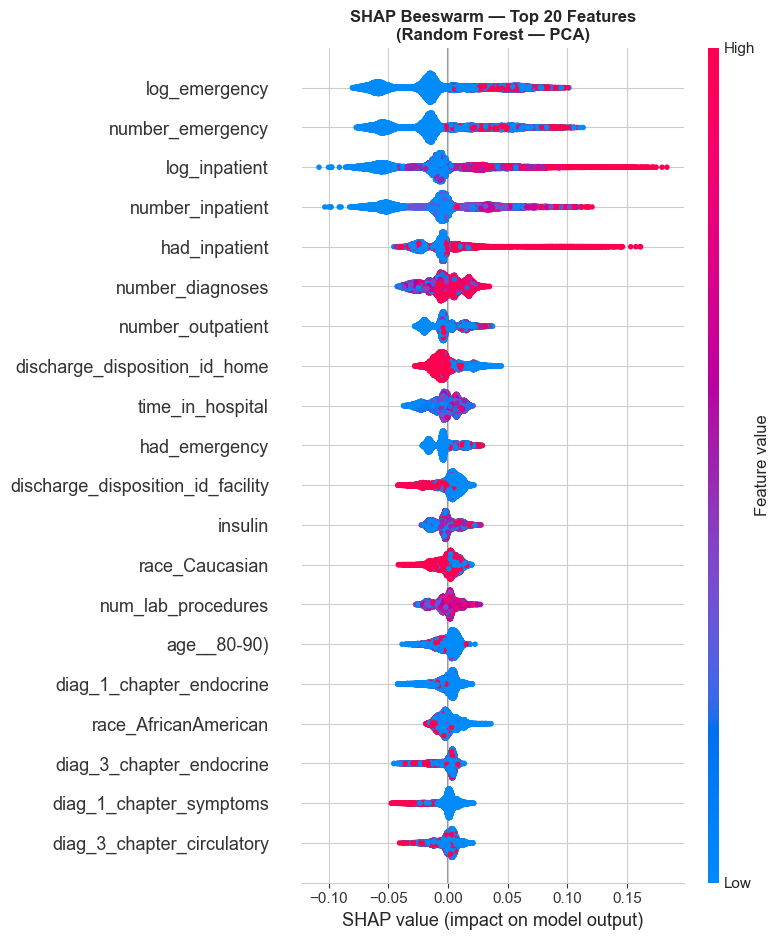

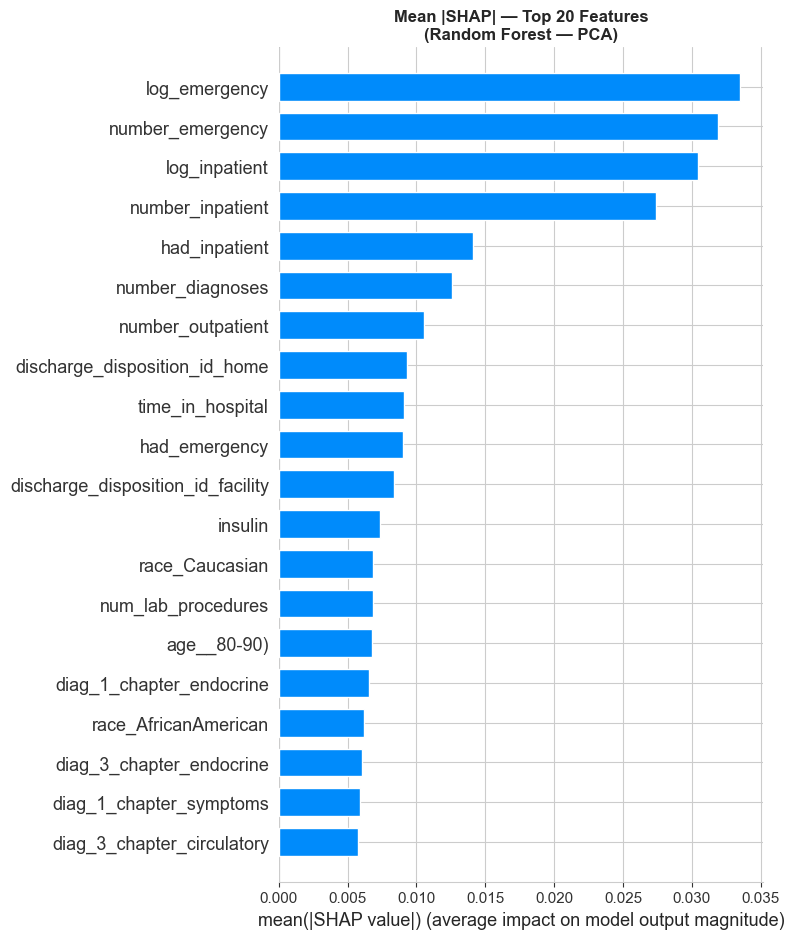


Top 10 features by mean |SHAP|:


,Mean |SHAP|
log_emergency,0.033478
number_emergency,0.031884
log_inpatient,0.030425
number_inpatient,0.027404
had_inpatient,0.014123
number_diagnoses,0.012553
number_outpatient,0.010579
discharge_disposition_id_home,0.009319
time_in_hospital,0.009093
had_emergency,0.009046


In [8]:
# Compute SHAP values (with PCA back-projection if needed)
shap_result = mt.compute_shap_values(
    best_model, best_X_te, is_pca_best,
    pca_transformer, mi_selected_features, X_test_sc,
)

shap_original  = shap_result["shap_original"]
feature_names  = shap_result["feature_names"]
X_display      = shap_result["X_display"]
mean_abs_shap  = shap_result["mean_abs_shap"]

# Beeswarm + bar SHAP summary plots
mt.plot_shap_summary(shap_original, X_display, feature_names, best_name)
plt.show()

# Top 10 most influential features
print("\nTop 10 features by mean |SHAP|:")
display(mean_abs_shap.head(10).to_frame())

In [9]:
from scipy.stats import spearmanr

X_vals = shap_result["X_display"].values
shap_vals = shap_result["shap_original"]

correlations = pd.Series(
    [spearmanr(X_vals[:, i], shap_vals[:, i]).statistic
     for i in range(len(feature_names))],
    index=feature_names,
)

driver_df = pd.DataFrame({
    "Mean |SHAP|":  mean_abs_shap,
    "Correlation":  correlations,
}).dropna().sort_values("Mean |SHAP|", ascending=False)

driver_df["Direction"] = driver_df["Correlation"].apply(
    lambda r: "↑ Higher value → more risk" if r > 0 else "↓ Higher value → less risk"
)

top_risk = driver_df[driver_df["Correlation"] > 0].head(5)
top_prot = driver_df[driver_df["Correlation"] <= 0].head(5)

print("Top 5 Risk Drivers — higher values increase readmission probability:")
display(top_risk[["Direction", "Mean |SHAP|", "Correlation"]].round(5))
print("\nTop 5 Protective Factors — higher values decrease readmission probability:")
display(top_prot[["Direction", "Mean |SHAP|", "Correlation"]].round(5))

Top 5 Risk Drivers — higher values increase readmission probability:


,Direction,Mean |SHAP|,Correlation
log_emergency,↑ Higher value → more risk,0.03348,0.41705
number_emergency,↑ Higher value → more risk,0.03188,0.40412
log_inpatient,↑ Higher value → more risk,0.03042,0.61649
number_inpatient,↑ Higher value → more risk,0.02740,0.61705
had_inpatient,↑ Higher value → more risk,0.01412,0.55014



Top 5 Protective Factors — higher values decrease readmission probability:


,Direction,Mean |SHAP|,Correlation
discharge_disposition_id_home,↓ Higher value → less risk,0.00932,-0.66037
discharge_disposition_id_facility,↓ Higher value → less risk,0.00835,-0.61609
race_Caucasian,↓ Higher value → less risk,0.00687,-0.47168
age__80-90),↓ Higher value → less risk,0.00677,-0.32993
diag_1_chapter_endocrine,↓ Higher value → less risk,0.00657,-0.01949


### 6.1 Explainability Summary — What Drives 30-Day Readmission?

Based on SHAP values back-projected to the original 117 clinical features, the model's predictions are dominated by a small set of clinically meaningful signals. The table above splits these into **risk drivers** (higher feature values push the prediction *toward* readmission) and **protective factors** (higher values push *away* from readmission), ranked by SHAP importance.

**How direction is determined:** We use the Spearman correlation between each feature's values and its SHAP contributions across all test patients. This avoids the pitfall of averaging signed SHAP values directly — which can be misleading for sparse features where most patients have zero values (e.g., prior emergency visits: most patients have none, so the population-average SHAP is negative, but patients *with* many prior emergencies are clearly at higher risk).

**Key themes across the top features:**

| Theme | What SHAP reveals | Clinical interpretation |
|---|---|---|
| **Utilisation history** | Prior emergency and inpatient encounters dominate feature importance | Repeated acute-care use reflects chronic, unresolved conditions — the strongest signal of future readmission |
| **Care complexity** | Number of diagnoses, lab procedures, length of stay | High comorbidity burden and intensive in-hospital workup indicate instability at discharge |
| **Discharge pathway** | Destination at discharge (home vs. facility) | Discharge to home is protective; facility discharge suggests the patient is too unwell for self-management |

> **Operational insight:** The top predictive signals — prior emergency and inpatient utilisation — are available in structured EHR data *at the point of admission*, not just at discharge. This enables proactive identification of high-risk patients well before discharge planning begins.

## 7. Fairness Analysis

Disparate model performance across demographic groups can perpetuate systemic inequities in healthcare resource allocation. The best model's performance is evaluated separately for each demographic subgroup using the one-hot-encoded indicators preserved in the original feature set:

- **Race subgroups** — columns matching `race_*`
- **Gender subgroups** — columns matching `gender_*`

Since the best model may operate on PCA features, predictions are generated on the PCA test set while demographic masking uses the original selected-feature test columns.

Key metrics: AUC-ROC, Recall, Precision, F1.

Race fairness:


,N,Positive Rate,AUC-ROC,Recall,Precision,F1
Group,,,,,,
Caucasian,15103,0.1143,0.6451,0.7389,0.1492,0.2482
Asian,121,0.0992,0.6514,0.5833,0.1750,0.2692
Other,270,0.0926,0.5535,0.5200,0.0977,0.1646
Unknown,433,0.0762,0.6958,0.5455,0.1250,0.2034
AfricanAmerican,3712,0.1158,0.6396,0.6558,0.1573,0.2537



Gender fairness:


,N,Positive Rate,AUC-ROC,Recall,Precision,F1
Group,,,,,,
Female,10805,0.1155,0.6405,0.7228,0.1513,0.2503
Male,9213,0.1110,0.6491,0.7087,0.1484,0.2454


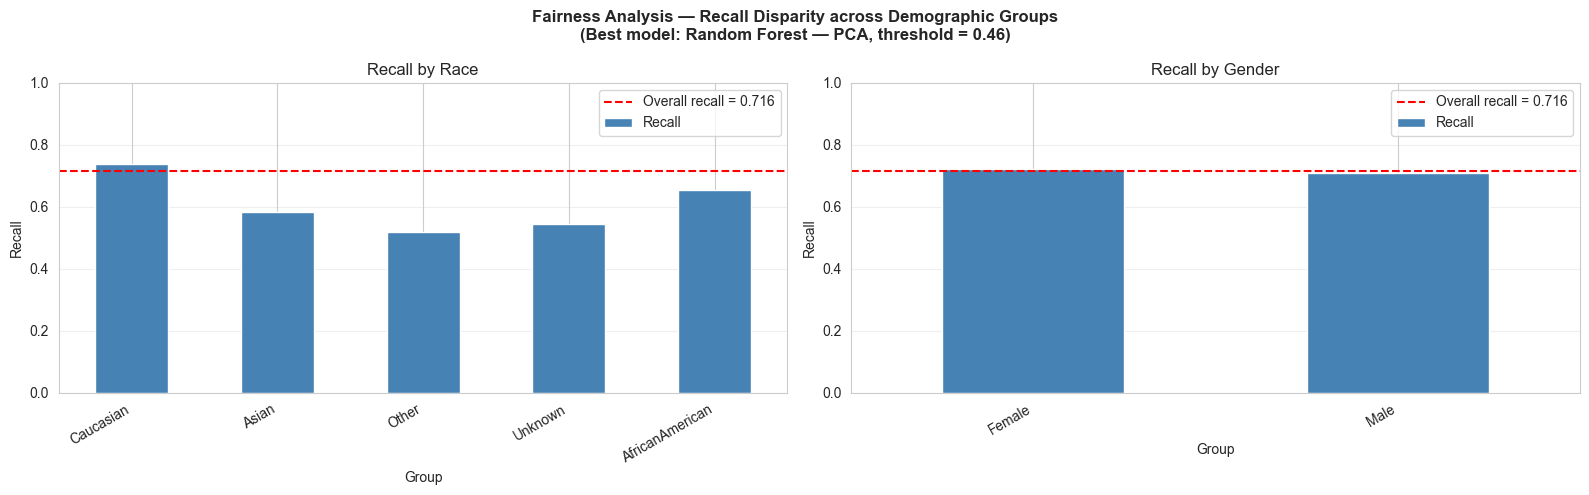

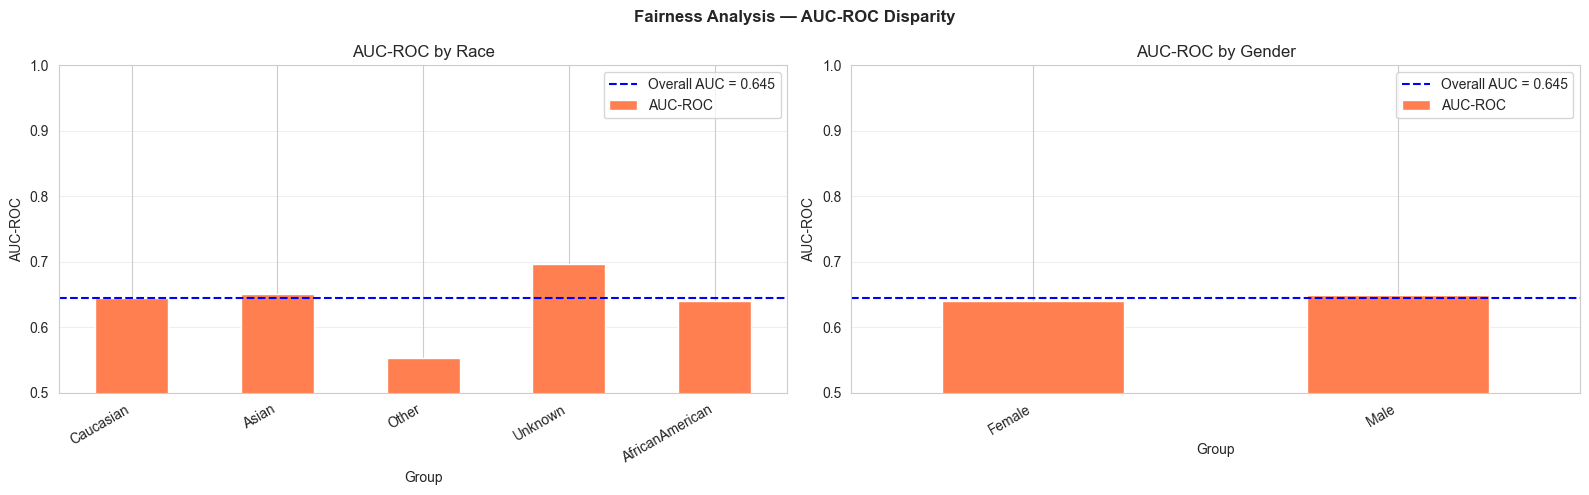

In [10]:
# Compute fairness metrics across race and gender subgroups
y_prob_final = best_model.predict_proba(best_X_te)[:, 1]

race_df = mt.compute_fairness_slices(
    "race_", X_test_sel, y_test, y_prob_final, y_pred_final,
)
gender_df = mt.compute_fairness_slices(
    "gender_", X_test_sel, y_test, y_prob_final, y_pred_final,
)

print("Race fairness:")
display(race_df)
print("\nGender fairness:")
display(gender_df)

# Recall and AUC disparity charts
mt.plot_fairness(
    race_df, gender_df, best_name,
    y_test, y_pred_final, y_prob_final, optimal_threshold,
)
plt.show()

## 8. Final Model Summary

This section consolidates all results, identifies the best model across all tracks (selected-feature and PCA), and saves the final model artifact to `models/`. The best model is selected dynamically based on **Test AUC** — the primary evaluation metric.

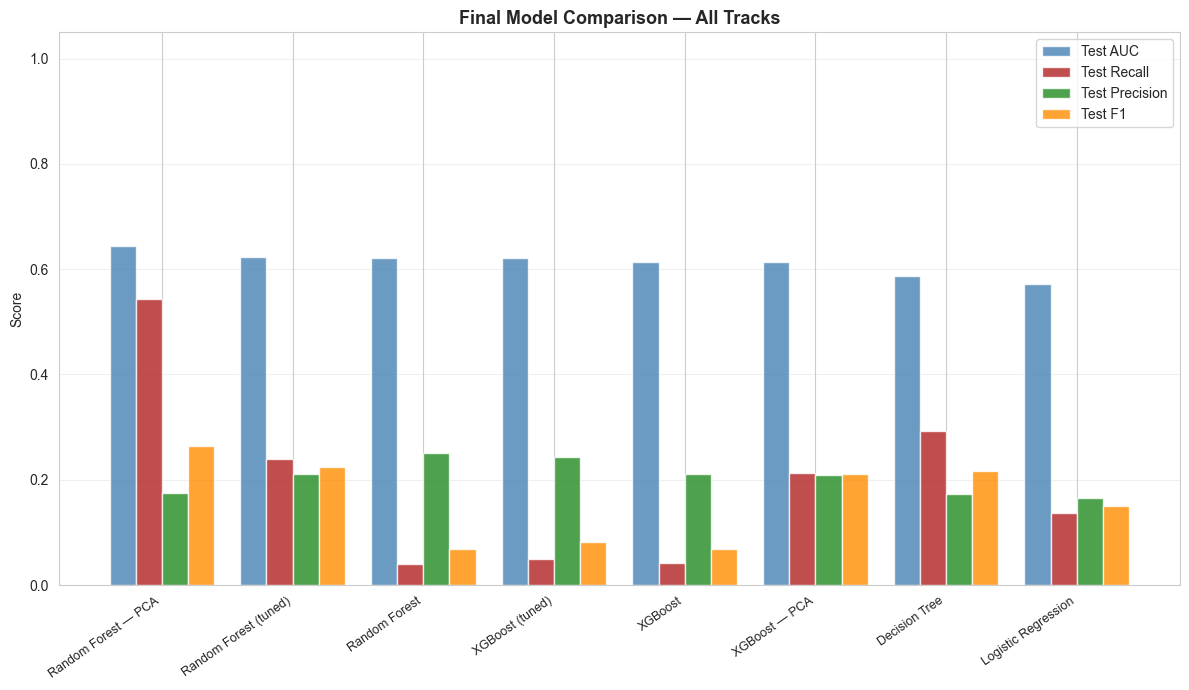

✓ Deployment pipeline: FeatureSelector → Scaler → Array → PCA → Model
✓ Best model saved: /Users/josefernandogonzales/Desktop/Solvin/Learning/Emeritus_AI/diabetic-readmission-prediction/models/best_model_random_forest_pca.joblib
✓ Metadata saved: best_model_metadata.json
✓ Feature list saved (117 features)
✓ StandardScaler saved
✓ PCA transformer saved
✓ Deployment pipeline saved

✓ All model artifacts saved to /Users/josefernandogonzales/Desktop/Solvin/Learning/Emeritus_AI/diabetic-readmission-prediction/models


In [11]:
# Final model comparison chart (all tracks)
mt.plot_final_model_comparison(all_results)
plt.show()

# Build deployment pipeline
deployment_pipeline = mt.build_deployment_pipeline(
    best_model, is_pca_best,
    mi_selected_features, scaler_artifact, pca_transformer,
)

# Export all model artifacts
models_dir = project_root / "models"
mt.export_artifacts(
    models_dir, best_name, best_model, optimal_threshold,
    all_results, y_test, y_pred_final, is_pca_best,
    mi_selected_features, scaler_artifact, pca_transformer,
    deployment_pipeline,
)

print(f"\n✓ All model artifacts saved to {models_dir}")

## 9. Deployment-Ready Pipeline

Notebook 02 saved the transformed **data CSVs** and the fitted preprocessing objects (StandardScaler, PCA transformer, feature-selection list). For production inference, a new patient encounter must pass through the same preprocessing chain before the model can score it.

This section builds and saves a deployment-ready `sklearn.Pipeline` that adapts to whichever model won:

- **If PCA model won**: Selects the 117 MI-selected features → scales continuous features → applies PCA → predicts with the tuned model and the clinically optimised threshold.
- **If non-PCA model won**: Selects the 117 MI-selected features → predicts directly (tree-based models don't need scaling).

Feature engineering (ICD-9 mapping, utilisation flags, one-hot encoding) is handled upstream by the `src/` preprocessing modules.

Additionally, the **StandardScaler**, **PCA transformer**, and **feature-selection column list** are saved as standalone artifacts so that alternative pipelines or retraining workflows can reuse them.

In [12]:
# Sanity-check: reload the deployment pipeline and verify predictions
saved = joblib.load(models_dir / "deployment_pipeline.joblib")
reloaded_pipeline = saved["pipeline"]
saved_threshold   = saved["optimal_threshold"]

# Load the original cleaned test data for an end-to-end test
df_test_raw = pd.read_csv(project_root / "data" / "processed" / "diabetic_data_cleaned.csv")
print(f"✓ Deployment pipeline reloaded  (threshold = {saved_threshold:.4f})")
print(f"  Pipeline steps: {[s[0] for s in reloaded_pipeline.steps]}")
print(f"  Expected features: {len(saved['features_expected'])}")

# Export summary tables
tables_dir = project_root / "reports" / "tables"
mt.export_tables(tables_dir, all_results, strategy_df, race_df, gender_df, mean_abs_shap)

# Export figures
figures_dir = project_root / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
mt.plot_baseline_roc(trained_models, y_test, results_df,
                     save_path=figures_dir / "fig_baseline_roc_v1.png")
mt.plot_pca_comparison(tuned_df, pca_df,
                       save_path=figures_dir / "fig_pca_comparison_v1.png")
mt.plot_threshold_analysis(best_name, threshold_result,
                           save_path=figures_dir / "fig_threshold_analysis_v1.png")
mt.plot_confusion_matrix_comparison(best_name, y_test, y_prob, optimal_threshold,
                                    save_path=figures_dir / "fig_confusion_threshold_v1.png")
mt.plot_shap_summary(shap_original, X_display, feature_names, best_name,
                     save_dir=figures_dir)
mt.plot_fairness(race_df, gender_df, best_name, y_test, y_pred_final, y_prob_final,
                 optimal_threshold, save_dir=figures_dir)
mt.plot_final_model_comparison(all_results,
                               save_path=figures_dir / "fig_model_comparison_v1.png")
plt.close("all")

print(f"\n✓ All figures exported to {figures_dir}")
print(f"✓ All tables exported to {tables_dir}")
print("\n✓ Notebook 03 complete — modeling, evaluation, and export pipeline finished.")

✓ Deployment pipeline reloaded  (threshold = 0.4556)
  Pipeline steps: ['feature_selector', 'scaler', 'to_array', 'pca', 'model']
  Expected features: 117
✓ 5 tables exported to /Users/josefernandogonzales/Desktop/Solvin/Learning/Emeritus_AI/diabetic-readmission-prediction/reports/tables

✓ All figures exported to /Users/josefernandogonzales/Desktop/Solvin/Learning/Emeritus_AI/diabetic-readmission-prediction/reports/figures
✓ All tables exported to /Users/josefernandogonzales/Desktop/Solvin/Learning/Emeritus_AI/diabetic-readmission-prediction/reports/tables

✓ Notebook 03 complete — modeling, evaluation, and export pipeline finished.
